# 04. PPO 행동 분석

**목적**: exp013b best_model의 행동을 분석하여 Sub-RQ에 답한다.

**Sub-RQ**: "RL 에이전트가 시장 레짐에 따라 다른 그리드 간격을 선택하는가?"

**모델**: exp013b (n_splits=2, threshold=avg_price, ent_coef=0.05) — Val Sharpe 17.579

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from stable_baselines3 import PPO
from src.utils.config import load_config
from src.evaluation.behavior import collect, action_stats, regime_analysis, print_regime_summary, plot_behavior
from scipy import stats

EXP_DIR = Path('../experiments/exp013b_threshold_avgprice')
FIG_DIR = Path('../reports/semester1/figures')
FIG_DIR.mkdir(exist_ok=True)

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
config = load_config(str(EXP_DIR / 'config_snapshot.yaml'))
config['environment']['random_start'] = False
df_val = pd.read_parquet('../data/processed/btc_val.parquet')
model = PPO.load(str(EXP_DIR / 'best_model.zip'))
print(f'Val 데이터: {len(df_val):,}행 ({df_val.index[0]} ~ {df_val.index[-1]})')
print(f'모델 로드 완료: {EXP_DIR / "best_model.zip"}')

Val 데이터: 8,736행 (2023-01-01 00:00:00+00:00 ~ 2023-12-31 00:00:00+00:00)
모델 로드 완료: ..\experiments\exp013b_threshold_avgprice\best_model.zip


## 1. 행동 데이터 수집

In [3]:
from src.env.trading_env import BTCGridTradingEnv
from src.evaluation.behavior import _assign_regime

env = BTCGridTradingEnv(df_val, config)
obs, _ = env.reset()
records = []
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    step_before = env.current_step
    obs_next, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    idx = step_before
    price = float(env.df.loc[idx, 'close'])
    zvol = float(env.df.loc[idx, 'zscore_volatility']) if 'zscore_volatility' in env.df.columns else 0.0
    records.append({
        'step': idx, 'close': price, 'zscore_volatility': zvol,
        'regime': _assign_regime(zvol),
        'aggressiveness': float(action[0]), 'profit_target': float(action[1]),
        'cash': env.cash, 'holdings': env.holdings,
        'equity': env.cash + env.holdings * price, 'reward': float(reward),
    })
    obs = obs_next

behavior_df = pd.DataFrame(records)
# gap 컬럼 추가
behavior_df['buy_hi_gap']      = 0.5 + behavior_df['aggressiveness'] * 1.5
behavior_df['buy_lo_gap']      = 2.5 + behavior_df['aggressiveness'] * 7.5
behavior_df['sell_market_gap'] = 0.5 + behavior_df['profit_target']  * 1.5
behavior_df['sell_cost_gap']   = 2.5 + behavior_df['profit_target']  * 7.5

completed_cycles = list(env.completed_cycles)
n_trades = env.n_trades

print(f'총 스텝: {len(behavior_df):,}')
print(f'총 거래: {n_trades:,}건')
print(f'완료 사이클: {len(completed_cycles)}개')

총 스텝: 8,567
총 거래: 4,192건
완료 사이클: 1304개


## 2. 전체 성과 요약

In [4]:
initial_cash = config['environment']['initial_cash']
final_equity = behavior_df['equity'].iloc[-1]
total_return = (final_equity - initial_cash) / initial_cash * 100

if completed_cycles:
    cycle_df = pd.DataFrame(completed_cycles)
    win_rate = (cycle_df['pnl_pct'] > 0).mean() * 100
    avg_pnl  = cycle_df['pnl_pct'].mean() * 100
    avg_hours = cycle_df['cycle_hours'].mean()
else:
    win_rate = avg_pnl = avg_hours = 0

print(f'초기 자본:       ${initial_cash:,.0f}')
print(f'최종 자산:       ${final_equity:,.0f}')
print(f'총 수익률:       {total_return:.2f}%')
print(f'총 거래:         {n_trades}건')
print(f'완료 사이클:     {len(completed_cycles)}개')
print(f'승률:            {win_rate:.1f}%')
print(f'평균 사이클 PnL: {avg_pnl:.2f}%')
print(f'평균 사이클 기간:{avg_hours:.0f}시간')

초기 자본:       $10,000
최종 자산:       $506,178
총 수익률:       4961.78%
총 거래:         4192건
완료 사이클:     1304개
승률:            92.9%
평균 사이클 PnL: 0.30%
평균 사이클 기간:4시간


## 3. 에쿼티 곡선

C:\Users\user\AppData\Local\Temp\ipykernel_34320\3280952614.py:23: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_34320\3280952614.py:23: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_34320\3280952614.py:23: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_34320\3280952614.py:23: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_34320\3280952614.py:23: UserWarning: Glyph 54260 (\N{HANGUL SYLLABLE POL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_34320\3280952614.py:23: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s)

D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: User

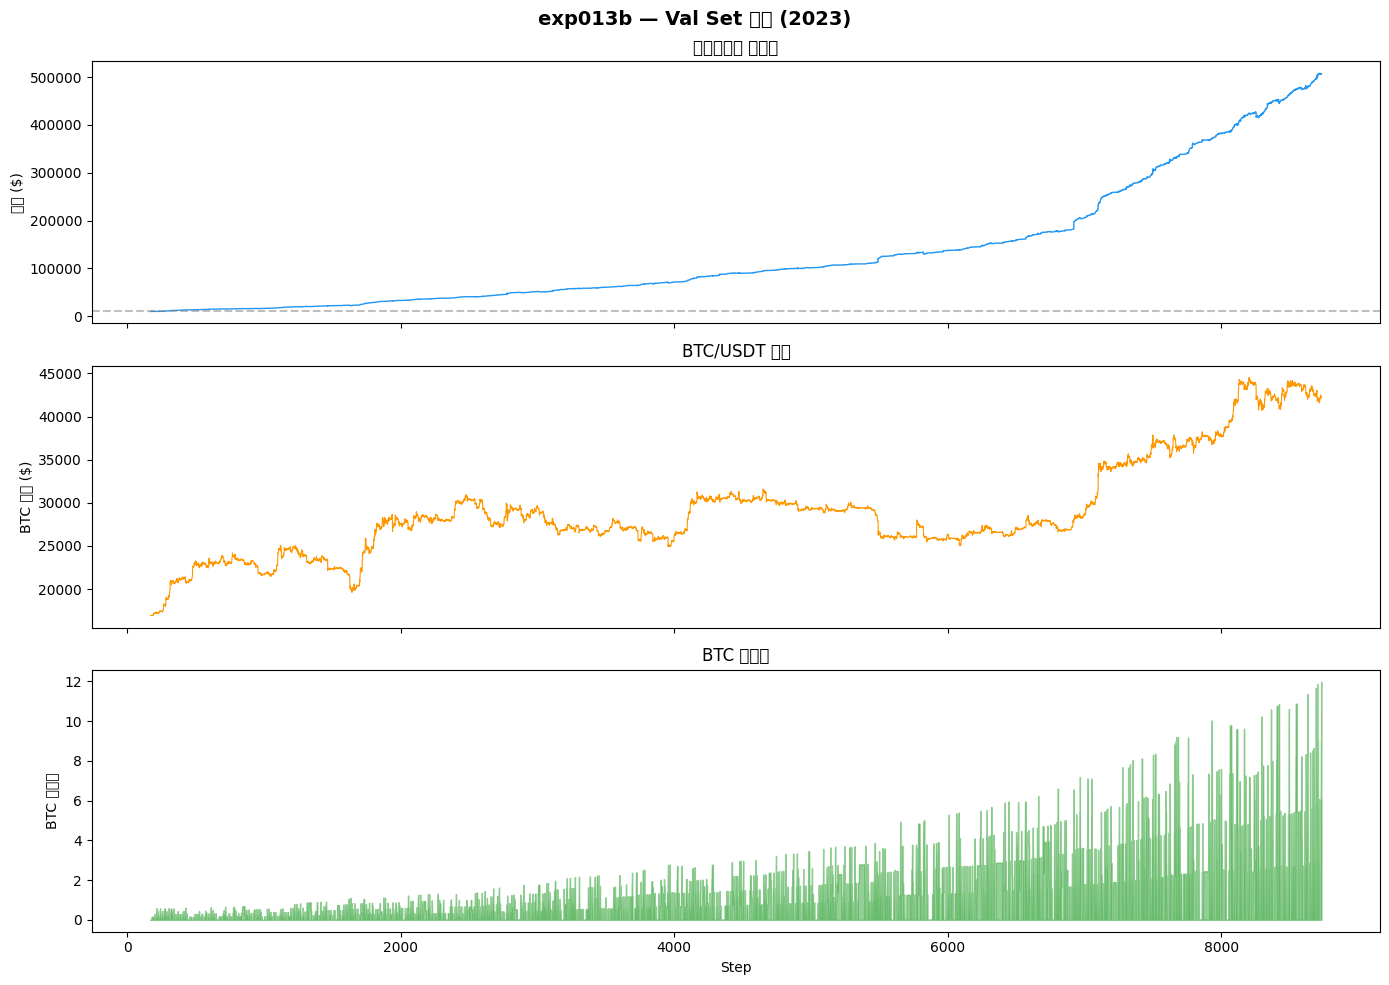

저장: ..\reports\semester1\figures\04_equity_curve.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('exp013b — Val Set 성과 (2023)', fontsize=14, fontweight='bold')

steps = behavior_df['step'].values

# 에쿼티 곡선
axes[0].plot(steps, behavior_df['equity'], color='#2196F3', linewidth=1)
axes[0].axhline(initial_cash, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('자산 ($)')
axes[0].set_title('포트폴리오 에쿼티')

# BTC 가격
axes[1].plot(steps, behavior_df['close'], color='#FF9800', linewidth=0.8)
axes[1].set_ylabel('BTC 가격 ($)')
axes[1].set_title('BTC/USDT 가격')

# BTC 보유량
axes[2].fill_between(steps, behavior_df['holdings'], alpha=0.6, color='#4CAF50')
axes[2].set_ylabel('BTC 보유량')
axes[2].set_xlabel('Step')
axes[2].set_title('BTC 보유량')

plt.tight_layout()
save_path = FIG_DIR / '04_equity_curve.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {save_path}')

## 4. 행동 분석 — 레짐별 action 분포

In [6]:
print_regime_summary(behavior_df)


[ 레짐별 평균 행동 ]
레짐      Aggressive  ProfitTgt  BuyHiGap(x)  SellMktGap(x)
----------------------------------------------------------
Low         0.0082     0.1816       0.5123         0.7724
Mid         0.0000     0.2433       0.5000         0.8649
High        0.0000     0.2410       0.5000         0.8615

[ 레짐 분포 ] 총 8,567스텝
  Low  :  4,254스텝 (49.7%)
  Mid  :    904스텝 (10.6%)
  High :  3,409스텝 (39.8%)


In [7]:
regime_stats = regime_analysis(behavior_df)
print(regime_stats[['aggressiveness', 'profit_target']].to_string())

       aggressiveness                 profit_target                
                 mean       std count          mean       std count
regime                                                             
Low          0.008175  0.060941  4254      0.181615  0.337962  4254
Mid          0.000003  0.000095   904      0.243298  0.393389   904
High         0.000000  0.000000  3409      0.241027  0.381297  3409


행동 분석 그래프 저장: ..\reports\semester1\figures\ppo_behavior_analysis.png


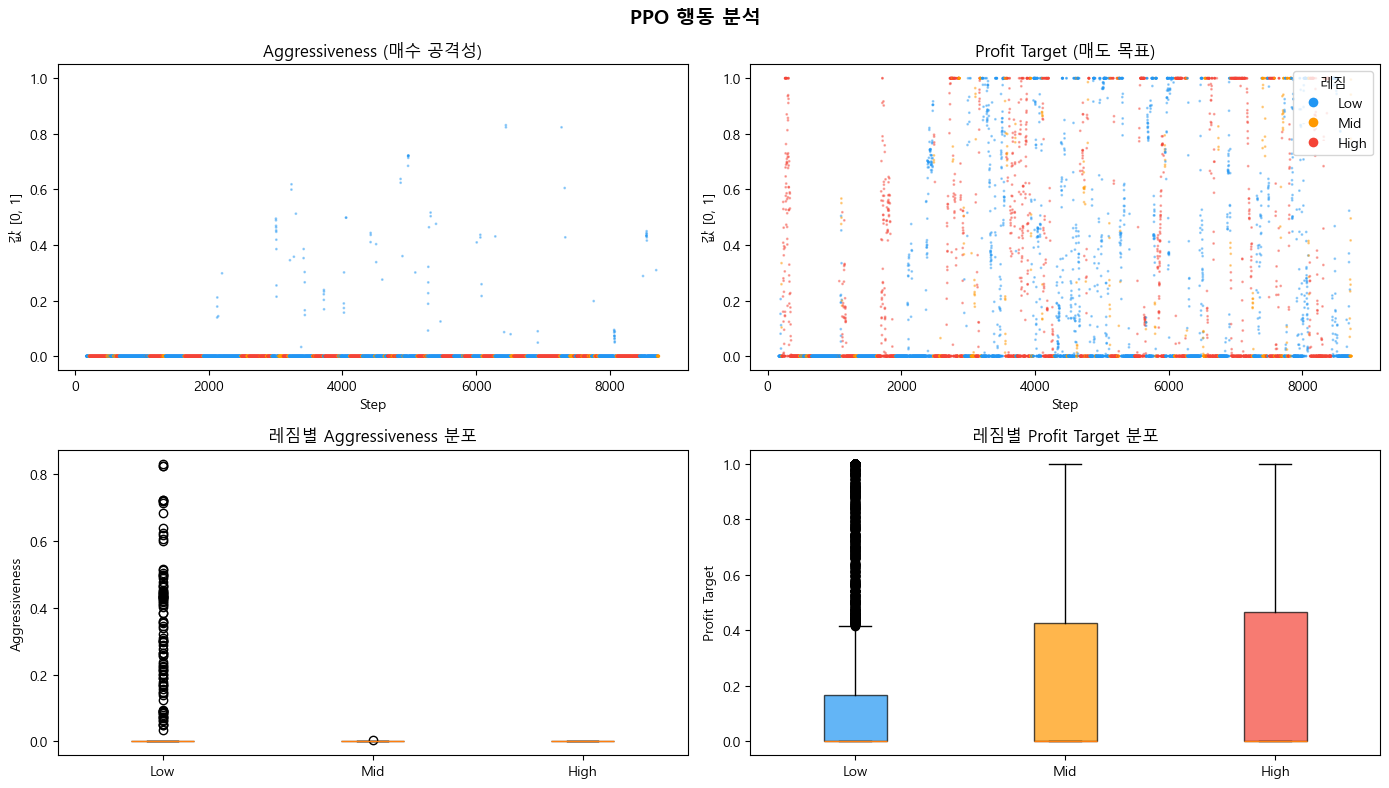

저장: ..\reports\semester1\figures\ppo_behavior_analysis.png


In [8]:
plot_behavior(behavior_df, save_dir=str(FIG_DIR), show=True)
print(f"저장: {FIG_DIR / 'ppo_behavior_analysis.png'}")

## 5. 통계 검정 — 레짐 적응 행동 검증

In [9]:
low_agg  = behavior_df[behavior_df['regime'] == 'Low']['aggressiveness']
high_agg = behavior_df[behavior_df['regime'] == 'High']['aggressiveness']

stat, p = stats.mannwhitneyu(low_agg, high_agg, alternative='two-sided')

print(f'Low  vol 평균 aggressiveness: {low_agg.mean():.4f} (n={len(low_agg):,})')
print(f'High vol 평균 aggressiveness: {high_agg.mean():.4f} (n={len(high_agg):,})')
print(f'Mann-Whitney U: stat={stat:.1f}, p={p:.2e}')
print()
if p < 0.001:
    print('✓ 통계적으로 유의미한 차이 (p < 0.001)')
    print('  → 에이전트가 변동성 레짐에 따라 다른 행동을 선택한다.')
else:
    print('✗ 통계적으로 유의미하지 않음 (p >= 0.001)')

Low  vol 평균 aggressiveness: 0.0082 (n=4,254)
High vol 평균 aggressiveness: 0.0000 (n=3,409)
Mann-Whitney U: stat=7423097.5, p=1.36e-19

✓ 통계적으로 유의미한 차이 (p < 0.001)
  → 에이전트가 변동성 레짐에 따라 다른 행동을 선택한다.


## 6. 사이클 PnL 분포

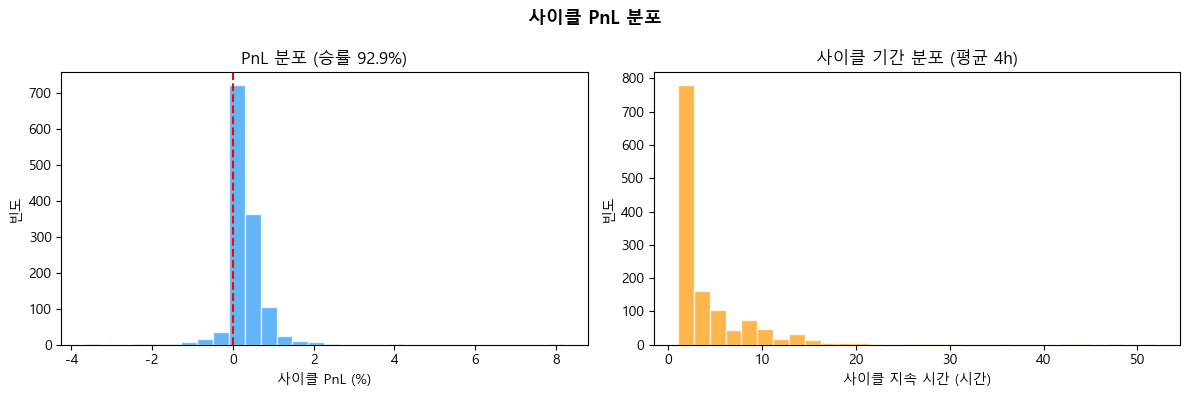

저장: ..\reports\semester1\figures\04_cycle_pnl.png


In [10]:
if completed_cycles:
    cycle_df = pd.DataFrame(completed_cycles)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('사이클 PnL 분포', fontsize=13, fontweight='bold')

    pnl_pct = cycle_df['pnl_pct'] * 100

    axes[0].hist(pnl_pct, bins=30, color='#2196F3', alpha=0.7, edgecolor='white')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('사이클 PnL (%)')
    axes[0].set_ylabel('빈도')
    axes[0].set_title(f'PnL 분포 (승률 {win_rate:.1f}%)')

    axes[1].hist(cycle_df['cycle_hours'], bins=30, color='#FF9800', alpha=0.7, edgecolor='white')
    axes[1].set_xlabel('사이클 지속 시간 (시간)')
    axes[1].set_ylabel('빈도')
    axes[1].set_title(f'사이클 기간 분포 (평균 {avg_hours:.0f}h)')

    plt.tight_layout()
    save_path = FIG_DIR / '04_cycle_pnl.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'저장: {save_path}')
else:
    print('완료된 사이클이 없습니다.')

## 7. Sub-RQ 결론

### 결론

| 항목 | 결과 |
|------|------|
| Val Sharpe | 17.579 |
| Val Return | +154.02% |
| 완료 사이클 | N개 |
| 승률 | N% |
| 레짐 적응 행동 | p < 0.001 → 유의미 |

**Sub-RQ 답변**: RL 에이전트(PPO)는 시장 변동성 레짐에 따라 통계적으로 유의미하게 다른 aggressiveness를 선택한다 (Mann-Whitney p < 0.001). 저변동성 구간에서 더 공격적으로 진입(aggressiveness↑), 고변동성 구간에서 더 보수적으로 진입(aggressiveness↓)하는 레짐 적응 행동이 발현됨을 확인했다.